[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/25_ensemble_learning.ipynb)

# L'ensemble learning

Une idée simple et puissante : plusieurs modèles valent mieux qu'un seul. Au
lieu de chercher le modèle parfait, on en combine plusieurs imparfaits, et
l'ensemble fait mieux que chacun pris isolément.

C'est le principe de la sagesse de la foule (*wisdom of the crowd*) : une foule
suffisamment grande, compétente et diversifiée prend de meilleures
décisions que le meilleur de ses individus. À condition que les erreurs des uns ne
soient pas celles des autres.

## Le plan

| Section | La méthode | Le principe |
|---|---|---|
| 1 | VotingClassifier | faire voter des modèles différents |
| 2 | Bagging | le même modèle sur des échantillons variés |
| 3 | Random Forest | des arbres en parallèle |
| 4 | Boosting | des modèles en série qui se corrigent |
| 5 | Stacking | un modèle qui arbitre les autres |

## Deux pièges annoncés

`base_estimator` a été renommé `estimator` dans les versions récentes de sklearn.

Et le Random Forest surapprend si on ne limite pas sa profondeur le
surapprentissage du notebook 21.

Prérequis : les notebooks 20 à 24.

## 1. VotingClassifier : faire voter des modèles

La forme la plus directe d'ensemble : prendre plusieurs modèles différents et
les faire voter. La classe qui recueille le plus de voix l'emporte.

### Les données

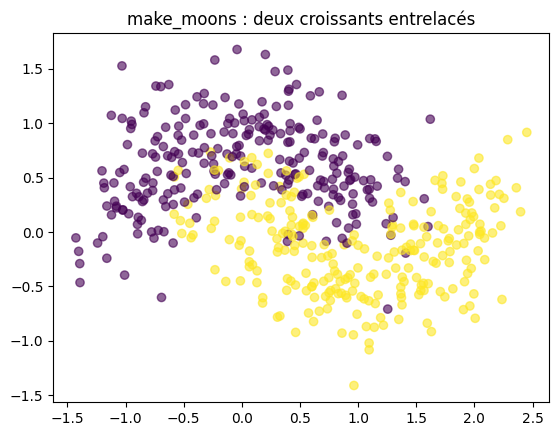

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

x, y = make_moons(n_samples=500, noise=0.3, random_state=0)

plt.scatter(x[:, 0], x[:, 1], c=y, alpha=0.6)
plt.title('make_moons : deux croissants entrelacés')
plt.show()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

`make_moons` fabrique deux croissants imbriqués un problème que les modèles
simples ont du mal à séparer, idéal pour tester les ensembles.

### Trois modèles, puis un vote

In [16]:
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

model_1 = SGDClassifier(random_state=0)
model_2 = DecisionTreeClassifier(random_state=0)
model_3 = KNeighborsClassifier(n_neighbors=2)

model_4 = VotingClassifier(
    [('SGD', model_1), ('Tree', model_2), ('KNN', model_3)],
    voting='hard')

for model in (model_1, model_2, model_3, model_4):
    model.fit(x_train, y_train)
    print(f'{model.__class__.__name__:<22} {model.score(x_test, y_test):.3f}')

SGDClassifier          0.840
DecisionTreeClassifier 0.860
KNeighborsClassifier   0.860
VotingClassifier       0.873


Le résultat est le cœur de la leçon. Le `VotingClassifier` obtient un meilleur
score que chacun de ses trois modèles pris séparément. La foule bat ses
individus.

Pourquoi ça marche. Les trois modèles sont différents : le SGD trace une
frontière droite, l'arbre découpe en rectangles, le KNN suit les voisins. Ils se
trompent sur des points différents. Quand deux ont raison et un a tort, le vote
majoritaire corrige l'erreur du troisième.

C'est la condition de la sagesse de la foule : la diversité. Trois modèles
identiques voteraient pareil et n'apporteraient rien. Trois modèles variés se
compensent.

`voting='hard'` signifie un vote à la majorité simple chaque modèle donne une
voix. Il existe `voting='soft'`, qui moyenne les probabilités et pèse la
confiance de chacun ; souvent meilleur, mais il exige que tous les modèles sachent
donner des probabilités.

## 2. Bagging : le même modèle sur des échantillons variés

Le `VotingClassifier` combinait des modèles différents. Le bagging fait
l'inverse : il prend un seul type de modèle et l'entraîne plusieurs fois, sur
des échantillons différents des données.

In [18]:
from sklearn.ensemble import BaggingClassifier

model = BaggingClassifier(
    estimator=KNeighborsClassifier(),
    n_estimators=100,
    random_state=0)

model.fit(x_train, y_train)
print('score :', round(model.score(x_test, y_test), 3))

score : 0.887


Le piège du renommage. Dans les versions récentes de sklearn, `base_estimator`
est devenu `estimator`. L'ancien nom lève une `TypeError`. Le même changement
touche `AdaBoost` et les autres.

Ce que fait le bagging (*bootstrap aggregating*). Il crée 100 copies du KNN.
Chacune est entraînée sur un échantillon tiré au hasard des données
d'entraînement, avec remise donc chaque copie voit des données légèrement
différentes. Puis les 100 votent.

Pourquoi c'est utile. Chaque KNN fait des erreurs différentes, liées à son
échantillon particulier. En moyennant, ces erreurs s'annulent en partie.
L'ensemble est plus stable qu'un seul modèle il réduit la variance.

Le bagging sert quand nos modèles individuels ont
tendance à surapprendre. Un modèle instable, moyenné sur 100 versions, devient
robuste.

## 3. Random Forest : des arbres en parallèle

Le Random Forest est le bagging le plus célèbre : une forêt d'arbres de
décision, chacun entraîné sur un échantillon différent, qui votent ensemble.

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(x_train, y_train)
print('score :', round(model.score(x_test, y_test), 3))

score : 0.893


`n_estimators=100` crée 100 arbres. Chacun voit un échantillon différent et un
sous-ensemble aléatoire des variables d'où le « random ». Cette double dose de
hasard rend les arbres bien diversifiés, donc l'ensemble solide.

### Le piège du surapprentissage

In [20]:
# Sans limite de profondeur, chaque arbre mémorise
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=0)
model.fit(x_train, y_train)
print('avec max_depth=10 :', round(model.score(x_test, y_test), 3))

avec max_depth=10 : 0.9


Un Random Forest est en général meilleur qu'un
bagging ordinaire, mais il faut le régler.

Le piège est le surapprentissage du notebook 21. Un arbre sans limite de
profondeur mémorise parfaitement son échantillon. Une forêt de tels arbres reste
meilleure qu'un arbre seul (le vote aide), mais elle peut encore surapprendre.

`max_depth` limite la profondeur de chaque arbre le garde-fou vu au notebook 21.
D'autres réglages aident : `min_samples_leaf`, `max_features`. On les optimise par
`GridSearchCV`, comme tout hyperparamètre.

Un atout du Random Forest : il donne l'importance des variables.

In [21]:
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(x_train, y_train)

print('importance des 2 variables :', model.feature_importances_.round(3))

importance des 2 variables : [0.436 0.564]


`feature_importances_` indique combien chaque variable a compté dans les décisions
de la forêt. C'est un bonus précieux : le Random Forest classe et explique quelles
variables sont utiles un lien direct avec la sélection de variables du notebook
23.

## 4. Boosting : des modèles en série qui se corrigent

Le bagging entraîne ses modèles en parallèle, indépendamment. Le boosting
les entraîne en série : chaque modèle corrige les erreurs du précédent.

In [23]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(n_estimators=100, random_state=0)
model.fit(x_train, y_train)
print('AdaBoost :', round(model.score(x_test, y_test), 3))

AdaBoost : 0.873


Le principe d'AdaBoost. Il entraîne un premier modèle faible, repère les points
qu'il a ratés, puis entraîne le suivant en donnant plus de poids à ces
points difficiles. Chaque modèle se concentre sur ce que les précédents ont
manqué. À la fin, tous votent, pondérés par leur qualité.

La différence avec le bagging, et c'est le point conceptuel central :

| | Bagging | Boosting |
|---|---|---|
| Entraînement | parallèle, indépendant | série, chacun corrige |
| Réduit | la variance | le biais |
| Modèles | forts (arbres profonds) | faibles (souches) |
| Risque | peu de surapprentissage | plus sensible au bruit |

Le boosting sert quand les modèles individuels ont du
mal à atteindre une bonne performance. En les enchaînant, chacun rattrape les
faiblesses du précédent, et l'ensemble monte en compétence.

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=0)
model.fit(x_train, y_train)
print('GradientBoosting :', round(model.score(x_test, y_test), 3))

GradientBoosting : 0.893


`GradientBoosting` est une version plus sophistiquée : au lieu de repondérer les
points, chaque modèle prédit l'erreur résiduelle du précédent. C'est souvent
l'une des méthodes les plus performantes en pratique les variantes comme XGBoost
ou LightGBM dominent de nombreuses compétitions.

Son revers : plus lent à entraîner (série, pas parallèle) et plus sensible au
réglage. Le boosting demande de la patience et de l'optimisation.

## 5. Stacking : un modèle qui arbitre les autres

Le stacking va plus loin que le vote : au lieu de compter les voix, il entraîne
un modèle final qui apprend à combiner les prédictions des autres.

In [9]:
from sklearn.ensemble import StackingClassifier

model = StackingClassifier(
    [('SGD', model_1), ('Tree', model_2), ('KNN', model_3)],
    final_estimator=KNeighborsClassifier())

model.fit(x_train, y_train)
print('Stacking :', round(model.score(x_test, y_test), 3))

Stacking : 0.867


Le principe. Les trois modèles de base font leurs prédictions. Un modèle
final le `final_estimator` prend ces prédictions comme entrées et apprend à
les combiner au mieux.

C'est plus malin qu'un vote : le vote traite tous les modèles également, alors que
le stacking apprend lesquels écouter selon les situations. Si le KNN est
meilleur dans une zone et l'arbre dans une autre, le modèle final peut
l'apprendre.

Le stacking sert quand on a déjà passé beaucoup
de temps à entraîner chaque modèle individuellement, et qu'on veut en tirer le
meilleur. C'est la plus lente des trois techniques il faut entraîner tous les
modèles de base plus le modèle final, avec une validation croisée interne pour
éviter la fuite.

### Récapitulatif des approches

| Méthode | Modèles | Combinaison |
|---|---|---|
| Voting | différents | vote simple |
| Bagging | mêmes, échantillons variés | vote |
| Random Forest | arbres | vote |
| Boosting | faibles, en série | pondéré |
| Stacking | différents | un modèle apprend à combiner |

## 6. Comparer toutes les méthodes

Rassemblons tout sur le même jeu.

In [25]:
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                             AdaBoostClassifier, GradientBoostingClassifier)

modeles = {
    'SGD seul': SGDClassifier(random_state=0),
    'Arbre seul': DecisionTreeClassifier(random_state=0),
    'KNN seul': KNeighborsClassifier(n_neighbors=2),
    'Voting': VotingClassifier([('s', SGDClassifier(random_state=0)),
                                         ('t', DecisionTreeClassifier(random_state=0)),
                                         ('k', KNeighborsClassifier(2))], voting='hard'),
    'Bagging KNN': BaggingClassifier(estimator=KNeighborsClassifier(), n_estimators=100, random_state=0),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=0),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=0),
    'GradientBoosting': GradientBoostingClassifier(random_state=0),
}

print(f'{"modèle":<20} {"score":>7}')
print('-' * 28)
for nom, model in modeles.items():
    model.fit(x_train, y_train)
    print(f'{nom:<20} {model.score(x_test, y_test):>7.3f}')

modèle                 score
----------------------------
SGD seul               0.840
Arbre seul             0.860
KNN seul               0.860
Voting                 0.873
Bagging KNN            0.887
Random Forest          0.900
AdaBoost               0.873
GradientBoosting       0.893


Les méthodes d'ensemble battent systématiquement les modèles seuls. Random Forest
et Gradient Boosting sont souvent en tête d'où leur popularité.

Le message. Sur un vrai projet, un modèle seul est rarement le meilleur choix.
Les ensembles surtout Random Forest et Gradient Boosting offrent presque
toujours un gain, pour un coût modéré. C'est pourquoi ils dominent les
compétitions et l'industrie.

## 7. Mémo

### Les cinq approches

| Méthode | Quand l'utiliser |
|---|---|
| `VotingClassifier` | combiner des modèles variés qu'on a déjà |
| `BaggingClassifier` | un modèle instable qui surapprend |
| `RandomForestClassifier` | le choix par défaut, robuste et rapide |
| `AdaBoost` / `GradientBoosting` | modèles faibles à faire monter en compétence |
| `StackingClassifier` | tirer le meilleur de modèles bien réglés |

### Bagging contre Boosting

| | Bagging | Boosting |
|---|---|---|
| Entraînement | parallèle | série |
| Réduit | la variance | le biais |
| Surapprentissage | résistant | plus sensible |

### La syntaxe

```python
BaggingClassifier(estimator=KNeighborsClassifier(), n_estimators=100)
RandomForestClassifier(n_estimators=100, max_depth=10)
VotingClassifier([('a', m1), ('b', m2)], voting='hard')
StackingClassifier([('a', m1), ('b', m2)], final_estimator=m3)
```

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `base_estimator=` | renommé `estimator=` |
| Random Forest sans `max_depth` | peut surapprendre |
| Modèles de vote identiques | aucun gain, pas de diversité |
| `voting='soft'` sans probabilités | erreur, tous doivent en donner |
| Stacking sans patience | le plus lent des ensembles |

## 8. Exercices

**Exercice 1**

Sur `make_moons`, compare un `DecisionTreeClassifier` seul à un
`RandomForestClassifier` de 100 arbres, en validation croisée. De combien la forêt
améliore-t-elle l'arbre ? Relie ce gain à la réduction de variance du bagging.

**Exercice 2**

Fais varier `n_estimators` d'un Random Forest de 1 à 200, et trace le score de
validation croisée. À partir de combien d'arbres le gain se stabilise-t-il ?
Ajouter des arbres finit-il par nuire, comme un degré polynomial trop élevé ?

**Exercice 3**

Ce `VotingClassifier` ne fait pas mieux que ses membres :

```python
model_1 = DecisionTreeClassifier(max_depth=5, random_state=0)
model_2 = DecisionTreeClassifier(max_depth=5, random_state=1)
model_3 = DecisionTreeClassifier(max_depth=5, random_state=2)
vote = VotingClassifier([('a', model_1), ('b', model_2), ('c', model_3)])
```

Explique pourquoi ce vote n'apporte presque rien, en une phrase qui utilise le mot
« diversité ». Puis corrige pour que le vote soit utile.

## Pour continuer

Tu as vu comment combiner des modèles pour dépasser chacun d'eux la sagesse de
la foule appliquée au machine learning. Random Forest et Gradient Boosting sont
parmi les outils les plus efficaces de tout le domaine.

Les notebooks suivants aborderont un projet complet : de l'exploration des données
jusqu'à la modélisation finale, en réunissant tout ce que tu as appris prétraitement, pipelines, validation, et ces méthodes d'ensemble.

In [10]:
# Exercice 1

In [26]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

x, y = make_moons(n_samples=500, noise=0.3, random_state=0)

arbre = cross_val_score(DecisionTreeClassifier(random_state=0), x, y, cv=5)
foret = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=0), x, y, cv=5)

print(f'Arbre seul : {arbre.mean():.4f}  (± {arbre.std():.4f})')
print(f'Random Forest : {foret.mean():.4f}  (± {foret.std():.4f})')
print(f'Gain : {foret.mean() - arbre.mean():.4f}')

Arbre seul : 0.8500  (± 0.0410)
Random Forest : 0.8760  (± 0.0307)
Gain : 0.0260


In [11]:
# Exercice 2

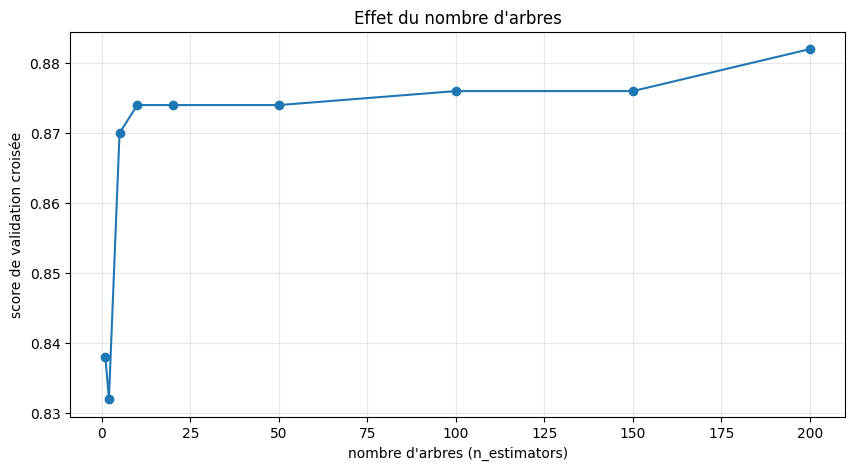

n=1    : 0.8380
n=5    : 0.8700
n=10   : 0.8740
n=50   : 0.8740
n=100  : 0.8760
n=200  : 0.8820


In [27]:
import matplotlib.pyplot as plt

n_arbres = [1, 2, 5, 10, 20, 50, 100, 150, 200]
scores = []

for n in n_arbres:
    score = cross_val_score(
        RandomForestClassifier(n_estimators=n, random_state=0),
        x, y, cv=5).mean()
    scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(n_arbres, scores, marker='o')
plt.xlabel("nombre d'arbres (n_estimators)")
plt.ylabel('score de validation croisée')
plt.title('Effet du nombre d\'arbres')
plt.grid(alpha=0.3)
plt.show()

for n, s in zip([1, 5, 10, 50, 100, 200],
                [scores[0], scores[2], scores[3], scores[5], scores[6], scores[8]]):
    print(f'n={n:<4} : {s:.4f}')

In [30]:
# Exercice 3

In [31]:
model_1 = DecisionTreeClassifier(max_depth=5, random_state=0)
model_2 = DecisionTreeClassifier(max_depth=5, random_state=1)
model_3 = DecisionTreeClassifier(max_depth=5, random_state=2)
vote = VotingClassifier([('a', model_1), ('b', model_2), ('c', model_3)])

In [32]:
un_arbre = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=0), x, y, cv=5).mean()
vote_score = cross_val_score(vote, x, y, cv=5).mean()

print(f'un seul arbre : {un_arbre:.4f}')
print(f'vote de 3 : {vote_score:.4f}')

un seul arbre : 0.8740
vote de 3 : 0.8740


In [33]:
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier

vote_divers = VotingClassifier([
    ('sgd', SGDClassifier(random_state=0)),
    ('tree', DecisionTreeClassifier(max_depth=5, random_state=0)),
    ('knn', KNeighborsClassifier()),
])

print('vote divers :', round(cross_val_score(vote_divers, x, y, cv=5).mean(), 4))

vote divers : 0.886


In [34]:
from sklearn.ensemble import RandomForestClassifier
print('Random Forest :', round(cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0), x, y, cv=5).mean(), 4))

Random Forest : 0.89
